In [2]:


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier
from IPython.display import clear_output
# numpy and pandas for data manipulation

# File system manangement
import os

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')


# matplotlib and seaborn for plotting
import seaborn as sns
import plotly.express as px


# from sklearnex import patch_sklearn
# patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()


In [4]:
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv')

# X_train = pd.read_csv('../data/X_train_fg.csv')
# X_test = pd.read_csv('../data/X_test_fg.csv')
# y_train = pd.read_csv('../data/y_train.csv')
# y_test = pd.read_csv('../data/y_test.csv')



cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)


y_train_int = y_train_enc

In [6]:
y_train_int

array([1, 0, 0, ..., 1, 1, 0])

# Model/Data selection 

In [ ]:

# Fill missing numeric values
# from sklearn.impute import SimpleImputer


# num_imputer = SimpleImputer(strategy='median')
# X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[num_cols]), columns=num_cols)
# X_test_num  = pd.DataFrame(num_imputer.transform(X_test[num_cols]), columns=num_cols)

# # Fill missing categorical values
# cat_imputer = SimpleImputer(strategy='most_frequent')
# X_train_cat = pd.DataFrame(cat_imputer.fit_transform(X_train[cat_cols]), columns=cat_cols)
# X_test_cat  = pd.DataFrame(cat_imputer.transform(X_test[cat_cols]), columns=cat_cols)


# # Combine numeric + categorical (we'll encode categoricals inside LazyClassifier)
# X_train_clean = pd.concat([X_train_num, X_train_cat], axis=1)
# X_test_clean  = pd.concat([X_test_num, X_test_cat], axis=1)



# =======================================
# Keep a small validation set (optional but safer) to check how the top models generalize.
# =======================================

# from sklearn.model_selection import train_test_split

# X_train_sub, X_val, y_train_sub, y_val = train_test_split(
#     X_train_clean, y_train, test_size=0.2, random_state=42, stratify=y_train
# )


clf = LazyClassifier(verbose=0,
                     ignore_warnings=True,
                     custom_metric=None,
                     predictions=False,
                     random_state=12,
                     classifiers='all'
                    )

models, predictions = clf.fit(X_train , None , y_train_int, None)
# clear_output()



line = px.line(data_frame= models ,y =["Accuracy"] , markers = True)
line.update_xaxes(title="Model",
              rangeslider_visible = False)
line.update_yaxes(title = "Accuracy")
line.update_traces(line_color="red")
line.update_layout(showlegend = True,
    title = {
        'text': 'Accuracy vs Model',
        'y':0.94,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'})

line.show()


line = px.line(data_frame= models ,y =["ROC AUC" , "F1 Score"] , markers = True)
line.update_xaxes(title="Model",
              rangeslider_visible = False)
line.update_yaxes(title = "ROC AUC SCORE")
line.update_layout(showlegend = True,
    title = {
        'text': 'ROC AUC and F1 Score vs Model',
        'y':0.94,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'})

line.show()




line = px.line(data_frame= models ,y =["Time Taken"] , markers = True)
line.update_xaxes(title="Model",
              rangeslider_visible = False)
line.update_yaxes(title = "Time(s)")
line.update_traces(line_color="purple")
line.update_layout(showlegend = True,
    title = {
        'text': 'TIME TAKEN vs Model',
        'y':0.94,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'})

line.show()

models

  0%|          | 0/29 [00:00<?, ?it/s]

# Randomforest for features selection

In [21]:
import plotly.graph_objs as go
import plotly.tools as tls
import plotly.offline as py

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=150, max_depth=8, min_samples_leaf=4, max_features=0.2, n_jobs=-1, random_state=0)
rf.fit(X_train, y_train)
features = X_train.columns.values
print("----- Training Done -----")

----- Training Done -----


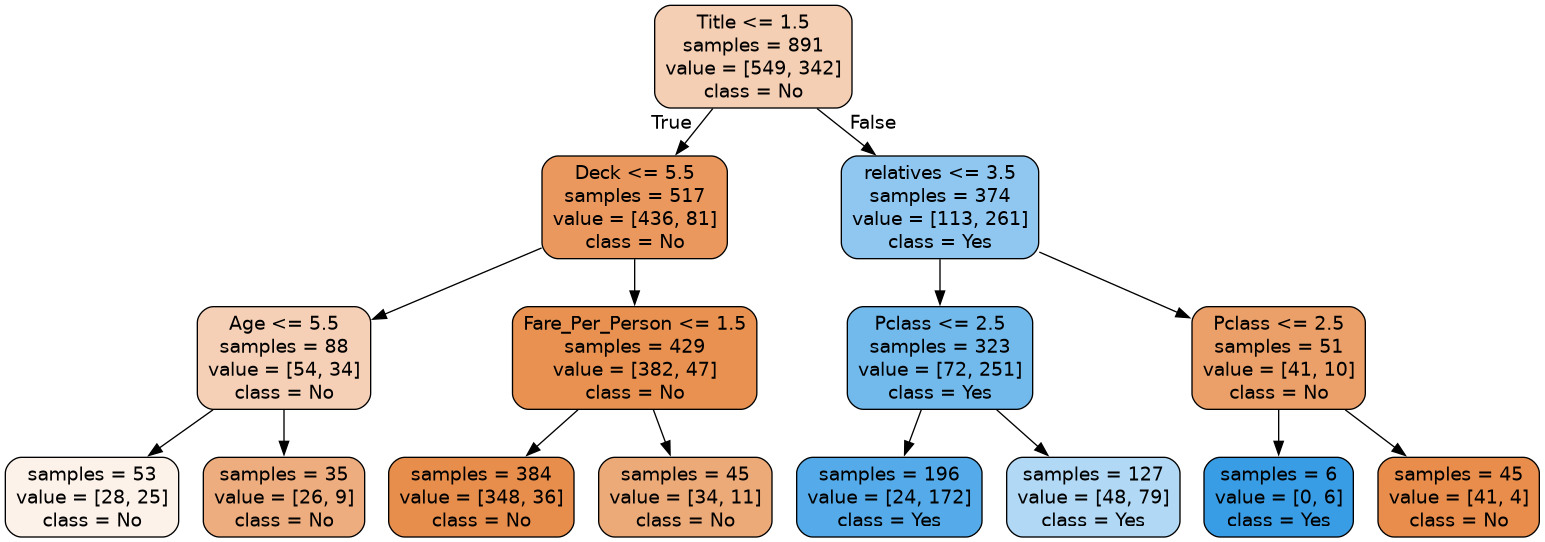

In [24]:
# Scatter plot 
trace = go.Scatter(
    y = rf.feature_importances_,
    x = features,
    mode='markers',
    marker=dict(
        sizemode = 'diameter',
        sizeref = 1,
        size = 13,
        #size= rf.feature_importances_,
        #color = np.random.randn(500), #set color equal to a variable
        color = rf.feature_importances_,
        colorscale='Portland',
        showscale=True
    ),
    text = features
)
data = [trace]

layout= go.Layout(
    autosize= True,
    title= 'Random Forest Feature Importance',
    hovermode= 'closest',
     xaxis= dict(
         ticklen= 5,
         showgrid=False,
        zeroline=False,
        showline=False
     ),
    yaxis=dict(
        title= 'Feature Importance',
        showgrid=False,
        zeroline=False,
        ticklen= 5,
        gridwidth= 2
    ),
    showlegend= False
)
fig = go.Figure(data=data, layout=layout)
py.iplot(fig,filename='scatter2010')


x, y = (list(x) for x in zip(*sorted(zip(rf.feature_importances_, features), 
                                                            reverse = False)))
trace2 = go.Bar(
    x=x ,
    y=y,
    marker=dict(
        color=x,
        colorscale = 'Viridis',
        reversescale = True
    ),
    name='Random Forest Feature importance',
    orientation='h',
)

layout = dict(
    title='Barplot of Feature importances',
     width = 900, height = 2000,
    yaxis=dict(
        showgrid=False,
        showline=False,
        showticklabels=True,
#         domain=[0, 0.85],
    ))

fig1 = go.Figure(data=[trace2])
fig1['layout'].update(layout)
py.iplot(fig1, filename='plots')



from sklearn import tree
from IPython.display import Image as PImage
from subprocess import check_call
from PIL import Image, ImageDraw, ImageFont
import re

decision_tree = tree.DecisionTreeClassifier(max_depth = 3)
decision_tree.fit(X_train, y_train)

# Export our trained model as a .dot file
with open("tree1.dot", 'w') as f:
     f = tree.export_graphviz(decision_tree,
                              out_file=f,
                              max_depth = 4,
                              impurity = False,
                              feature_names = X_train.columns.values,
                              class_names = ['No', 'Yes'],
                              rounded = True,
                              filled= True )
        
#Convert .dot to .png to allow display in web notebook
check_call(['dot','-Tpng','tree1.dot','-o','tree1.png'])

# Annotating chart with PIL
img = Image.open("tree1.png")
draw = ImageDraw.Draw(img)
img.save('sample-out.png')
PImage("sample-out.png",)

**Feature importance via Gradient Boosting model**

In [25]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(n_estimators=100, max_depth=3, min_samples_leaf=4, max_features=0.2, random_state=0)
gb.fit(X_train, y_train)
features = X_train.columns.values
print("----- Training Done -----")


# Scatter plot 
trace = go.Scatter(
    y = gb.feature_importances_,
    x = features,
    mode='markers',
    marker=dict(
        sizemode = 'diameter',
        sizeref = 1,
        size = 13,
        #size= rf.feature_importances_,
        #color = np.random.randn(500), #set color equal to a variable
        color = gb.feature_importances_,
        colorscale='Portland',
        showscale=True
    ),
    text = features
)
data = [trace]

layout= go.Layout(
    autosize= True,
    title= 'Gradient Boosting Machine Feature Importance',
    hovermode= 'closest',
     xaxis= dict(
         ticklen= 5,
         showgrid=False,
        zeroline=False,
        showline=False
     ),
    yaxis=dict(
        title= 'Feature Importance',
        showgrid=False,
        zeroline=False,
        ticklen= 5,
        gridwidth= 2
    ),
    showlegend= False
)
fig = go.Figure(data=data, layout=layout)
py.iplot(fig,filename='scatter2010')




x, y = (list(x) for x in zip(*sorted(zip(gb.feature_importances_, features), 
                                                            reverse = False)))
trace2 = go.Bar(
    x=x ,
    y=y,
    marker=dict(
        color=x,
        colorscale = 'Viridis',
        reversescale = True
    ),
    name='Gradient Boosting Classifer Feature importance',
    orientation='h',
)

layout = dict(
    title='Barplot of Feature importances',
     width = 900, height = 2000,
    yaxis=dict(
        showgrid=False,
        showline=False,
        showticklabels=True,
    ))

fig1 = go.Figure(data=[trace2])
fig1['layout'].update(layout)
py.iplot(fig1, filename='plots')



----- Training Done -----


# Other Models

In [8]:
# Load Data
# -------------------------------
X_train_encoded = pd.read_csv('../data/X_train_encoded.csv')
X_test_encoded  = pd.read_csv('../data/X_test_encoded.csv')
y_train = pd.read_csv('../data/y_train.csv')
test_ids = X_test_encoded['PassengerId']
X_test_encoded.drop(columns=['PassengerId'], inplace=True)

# Flatten target if needed
# Map target to numeric
target = 'Survived'

y_train_numeric = y_train[target]


num_classes = len(np.unique(y_train_numeric))
print(f"Number of classes: {num_classes}")

print("X_train shape:", X_train_encoded.shape)
print("X_test shape:", X_test_encoded.shape)

Number of classes: 2
X_train shape: (891, 13)
X_test shape: (418, 13)


In [10]:
import time
import pandas as pd
from sklearn import (
    discriminant_analysis,
    ensemble,
    linear_model,
    naive_bayes,
    svm,
    tree,
    neighbors,
    model_selection
)
from xgboost import XGBClassifier


# =========================
# Models
# =========================

MLA = [

    # Ensemble
    ensemble.AdaBoostClassifier(),
    ensemble.BaggingClassifier(),
    ensemble.ExtraTreesClassifier(n_estimators=200, random_state=42),
    ensemble.GradientBoostingClassifier(),
    ensemble.RandomForestClassifier(n_estimators=200, random_state=42),

    # Linear
    linear_model.LogisticRegressionCV(max_iter=1000),
    linear_model.RidgeClassifierCV(),
    linear_model.SGDClassifier(random_state=42),
    linear_model.Perceptron(random_state=42),

    # Naive Bayes
    naive_bayes.BernoulliNB(),
    naive_bayes.GaussianNB(),

    # Neighbors
    neighbors.KNeighborsClassifier(),

    # SVM
    svm.SVC(probability=True),
    svm.NuSVC(probability=True),

    # Trees
    tree.DecisionTreeClassifier(random_state=42),
    tree.ExtraTreeClassifier(random_state=42),

    # Discriminant Analysis
    discriminant_analysis.LinearDiscriminantAnalysis(),
    discriminant_analysis.QuadraticDiscriminantAnalysis(),

    # XGBoost
    XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_estimators=300,
        n_jobs=4
    )
]


# =========================
# CV Strategy (STRATIFIED)
# =========================

cv_split = model_selection.StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# =========================
# Results Table
# =========================

MLA_compare = pd.DataFrame(columns=[
    'MLA Name',
    'Train Accuracy Mean',
    'CV Accuracy Mean',
    'CV Accuracy 3*STD',
    'Fit Time'
])

MLA_predict = pd.DataFrame(index=X_test.index)

# =========================
# Train + CV
# =========================

for i, alg in enumerate(MLA):
    name = alg.__class__.__name__
    start = time.time()

    cv_results = model_selection.cross_validate(
        alg,
        X_train,
        y_train,
        cv=cv_split,
        scoring='accuracy',
        return_train_score=True,
        n_jobs=-1
    )

    MLA_compare.loc[i] = [
        name,
        cv_results['train_score'].mean(),
        cv_results['test_score'].mean(),
        cv_results['test_score'].std() * 3,
        cv_results['fit_time'].mean()
    ]

    # Fit full model and predict TEST (no labels)
    alg.fit(X_train, y_train)
    MLA_predict[name] = alg.predict(X_test)


# =========================
# Rank models
# =========================

MLA_compare.sort_values(
    by='CV Accuracy Mean',
    ascending=False,
    inplace=True
)

MLA_compare


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is de

,MLA Name,Train Accuracy Mean,CV Accuracy Mean,CV Accuracy 3*STD,Fit Time
3,GradientBoostingClassifier,0.89,0.83,0.10,0.08
0,AdaBoostClassifier,0.84,0.82,0.06,0.06
13,NuSVC,0.82,0.82,0.04,0.05
4,RandomForestClassifier,0.93,0.81,0.06,0.17
12,SVC,0.82,0.81,0.05,0.04
1,BaggingClassifier,0.93,0.81,0.08,0.02
5,LogisticRegressionCV,0.82,0.81,0.04,0.10
6,RidgeClassifierCV,0.81,0.80,0.03,0.01
2,ExtraTreesClassifier,0.93,0.80,0.05,0.14
16,LinearDiscriminantAnalysis,0.81,0.80,0.04,0.00


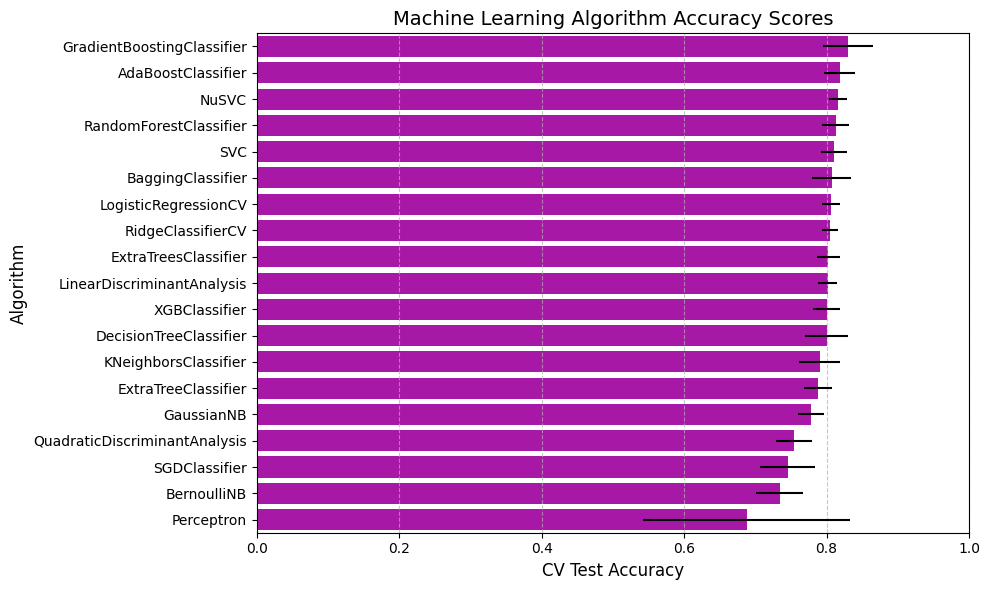

,MLA Name,Train Accuracy Mean,CV Accuracy Mean,CV Accuracy 3*STD,Fit Time
0,GradientBoostingClassifier,0.89,0.83,0.10,0.08
1,AdaBoostClassifier,0.84,0.82,0.06,0.06
2,NuSVC,0.82,0.82,0.04,0.05
3,RandomForestClassifier,0.93,0.81,0.06,0.17
4,SVC,0.82,0.81,0.05,0.04
5,BaggingClassifier,0.93,0.81,0.08,0.02
6,LogisticRegressionCV,0.82,0.81,0.04,0.10
7,RidgeClassifierCV,0.81,0.80,0.03,0.01
8,ExtraTreesClassifier,0.93,0.80,0.05,0.14
9,LinearDiscriminantAnalysis,0.81,0.80,0.04,0.00


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by CV Accuracy for best-to-worst plotting
MLA_compare_sorted = MLA_compare.sort_values(
    by='CV Accuracy Mean',
    ascending=False
).reset_index(drop=True)

# Plot horizontal bar chart with error bars
plt.figure(figsize=(10, 6))
sns.barplot(
    x='CV Accuracy Mean',              # use the correct column name
    y='MLA Name',
    data=MLA_compare_sorted,
    xerr=MLA_compare_sorted['CV Accuracy 3*STD'] / 3,  # divide by 3 to get std
    color='m'
)

plt.title('Machine Learning Algorithm Accuracy Scores', fontsize=14)
plt.xlabel('CV Test Accuracy', fontsize=12)
plt.ylabel('Algorithm', fontsize=12)
plt.xlim(0, 1)  # accuracy scale from 0 to 1
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Display the sorted table
MLA_compare_sorted


- compare algorithm predictions with each other, where 1 = exactly similar and 0 = exactly opposite

- there are some 1's, but enough blues and light reds to create a "super algorithm" by combining them

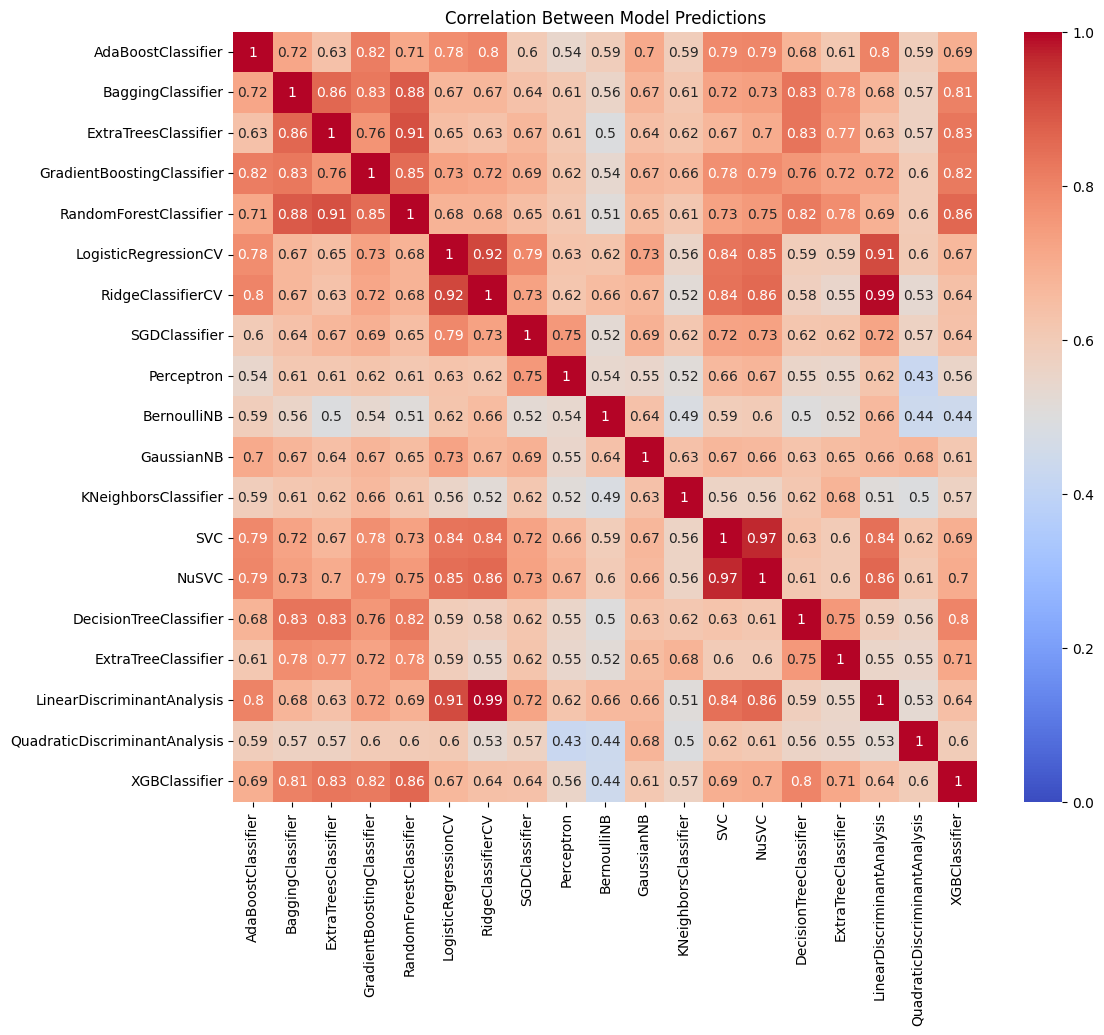

In [15]:
# ---------- Correlation Heatmap of Predictions ----------
corr_matrix = MLA_predict.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Correlation Between Model Predictions")
plt.show()

# Voting classifier

removed models w/o attribute 'predict_proba' required for vote classifier and models with a 1.0 correlation to another model


In [18]:
import pandas as pd
from sklearn import ensemble, linear_model, naive_bayes, neighbors, svm
from xgboost import XGBClassifier
from sklearn import model_selection

# ----------------------
# Define base estimators
# ----------------------
vote_est = [
    ('ada', ensemble.AdaBoostClassifier()),
    ('bc', ensemble.BaggingClassifier()),
    ('etc', ensemble.ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('gbc', ensemble.GradientBoostingClassifier()),
    ('rfc', ensemble.RandomForestClassifier(n_estimators=100, random_state=42)),
    ('lr', linear_model.LogisticRegressionCV(max_iter=1000)),
    ('bnb', naive_bayes.BernoulliNB()),
    ('gnb', naive_bayes.GaussianNB()),
    ('knn', neighbors.KNeighborsClassifier()),
    ('svc', svm.SVC(probability=True)),
    ('xgb', XGBClassifier(eval_metric='logloss', use_label_encoder=False, n_estimators=200, random_state=42))
]

cv_split = model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ----------------------
# Hard Voting
# ----------------------
vote_hard = ensemble.VotingClassifier(
    estimators=vote_est,
    voting='hard',
    n_jobs=-1
)

vote_hard_cv = model_selection.cross_validate(
    vote_hard,
    X_train,
    y_train,
    cv=cv_split,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)

vote_hard.fit(X_train, y_train)

print("Hard Voting Training Accuracy: {:.2f}%".format(vote_hard_cv['train_score'].mean() * 100))
print("Hard Voting CV Accuracy: {:.2f}%".format(vote_hard_cv['test_score'].mean() * 100))
print("Hard Voting CV 3*STD: ±{:.2f}%".format(vote_hard_cv['test_score'].std() * 100 * 3))

# Prepare submission (Hard Voting)
pred_test_hard = vote_hard.predict(X_test)
submission_hard = pd.DataFrame({
    "PassengerId": test_ids,  # your test IDs
    "Survived": pred_test_hard
})
submission_hard.to_csv("submission/base_models_hard_voting_submission.csv", index=False)
print("Hard Voting submission saved!")

# ----------------------
# Soft Voting
# ----------------------
vote_soft = ensemble.VotingClassifier(
    estimators=vote_est,
    voting='soft',
    n_jobs=-1
)

vote_soft_cv = model_selection.cross_validate(
    vote_soft,
    X_train,
    y_train,
    cv=cv_split,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)

vote_soft.fit(X_train, y_train)

print("Soft Voting Training Accuracy: {:.2f}%".format(vote_soft_cv['train_score'].mean() * 100))
print("Soft Voting CV Accuracy: {:.2f}%".format(vote_soft_cv['test_score'].mean() * 100))
print("Soft Voting CV 3*STD: ±{:.2f}%".format(vote_soft_cv['test_score'].std() * 100 * 3))

# Prepare submission (Soft Voting)
pred_test_proba_soft = vote_soft.predict_proba(X_test)[:, 1]
pred_test_soft = (pred_test_proba_soft >= 0.5).astype(int)

submission_soft = pd.DataFrame({
    "PassengerId": test_ids,  # your test IDs
    "Survived": pred_test_soft
})
submission_soft.to_csv("submission/base_models_soft_voting_submission.csv", index=False)
print("Soft Voting submission saved!")


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:97: DataConve

Hard Voting Training Accuracy: 89.51%
Hard Voting CV Accuracy: 81.93%
Hard Voting CV 3*STD: ±7.22%
Hard Voting submission saved!


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:97: DataConve

Soft Voting Training Accuracy: 90.96%
Soft Voting CV Accuracy: 82.15%
Soft Voting CV 3*STD: ±5.41%
Soft Voting submission saved!


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [10:04:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Soft Voting Test Accuracy: 79.99%


In [19]:
import time
from sklearn import model_selection
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier
)
from sklearn.naive_bayes import BernoulliNB, GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.linear_model import LogisticRegressionCV


from sklearn.model_selection import StratifiedKFold

cv_split = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=0
)

# ===============================
# PARAMETER GRIDS
# ===============================
grid_n_estimator = [10, 50, 100, 300]
grid_ratio = [.1, .25, .5, .75, 1.0]
grid_learn = [.01, .03, .05, .1, .25]
grid_max_depth = [2, 4, 6, 8, 10, None]
grid_criterion = ['gini', 'entropy']
grid_bool = [True, False]
grid_seed = [0]

# ===============================
# ESTIMATORS
# ===============================
vote_est = [
    ("AdaBoost", AdaBoostClassifier()),
    ("Bagging", BaggingClassifier()),
    ("ExtraTrees", ExtraTreesClassifier()),
    ("GradientBoosting", GradientBoostingClassifier()),
    ("RandomForest", RandomForestClassifier()),
    ("GaussianProcess", GaussianProcessClassifier()),
    ("BernoulliNB", BernoulliNB()),
    ("GaussianNB", GaussianNB()),
    ("KNN", KNeighborsClassifier()),
    ("SVC", SVC()),
]

# ===============================
# GRIDS (MATCH ORDER ABOVE)
# ===============================
grid_param = [
    {  # AdaBoost
        'n_estimators': grid_n_estimator,
        'learning_rate': grid_learn,
        'random_state': grid_seed
    },
    {  # Bagging
        'n_estimators': grid_n_estimator,
        'max_samples': grid_ratio,
        'random_state': grid_seed
    },
    {  # ExtraTrees
        'n_estimators': grid_n_estimator,
        'criterion': grid_criterion,
        'max_depth': grid_max_depth,
        'random_state': grid_seed
    },
    {  # GradientBoosting
        'learning_rate': [0.05],
        'n_estimators': [300],
        'max_depth': grid_max_depth,
        'random_state': grid_seed
    },
    {  # RandomForest
        'n_estimators': grid_n_estimator,
        'criterion': grid_criterion,
        'max_depth': grid_max_depth,
        'oob_score': [True],
        'random_state': grid_seed
    },
    {  # GaussianProcess
        'max_iter_predict': grid_n_estimator,
        'random_state': grid_seed
    },
    {  # BernoulliNB
        'alpha': grid_ratio
    },
    {},  # GaussianNB (no hyperparameters)
    {  # KNN
        'n_neighbors': [1,2,3,4,5,6,7],
        'weights': ['uniform', 'distance'],
        'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
    },
    {  # SVC
        'C': [1,2,3,4,5],
        'gamma': grid_ratio,
        'decision_function_shape': ['ovo', 'ovr'],
        'probability': [True],
        'random_state': grid_seed
    }
]

# ===============================
# GRID SEARCH LOOP
# ===============================
start_total = time.perf_counter()

for (name, clf), param in zip(vote_est, grid_param):

    start = time.perf_counter()

    gs = model_selection.GridSearchCV(
        estimator=clf,
        param_grid=param,
        cv=cv_split,
        scoring='roc_auc',
        n_jobs=10
    )

    gs.fit(X_train_encoded, y_train)

    run = time.perf_counter() - start

    print(
        f"The best parameter for {name} is {gs.best_params_} "
        f"with a runtime of {run:.2f} seconds."
    )

    clf.set_params(**gs.best_params_)

run_total = time.perf_counter() - start_total
print(f"Total optimization time was {run_total/60:.2f} minutes.")
print('-'*10)

# ===============================
# LOGISTIC REGRESSION (SPECIAL CASE)
# ===============================
lr = LogisticRegressionCV(
    cv=cv_split,
    scoring='roc_auc',
    max_iter=500,
    random_state=0
)

lr.fit(X_train_encoded, y_train)
print("LogisticRegressionCV fitted separately.")


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is de

The best parameter for AdaBoost is {'learning_rate': 0.25, 'n_estimators': 50, 'random_state': 0} with a runtime of 4.57 seconds.


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:782: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:782: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:782: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:782: DataConversionWarning: A column-vector y was 

The best parameter for Bagging is {'max_samples': 0.1, 'n_estimators': 100, 'random_state': 0} with a runtime of 3.10 seconds.


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed

...

The best parameter for GaussianProcess is {'max_iter_predict': 10, 'random_state': 0} with a runtime of 4.05 seconds.
The best parameter for BernoulliNB is {'alpha': 0.1} with a runtime of 0.12 seconds.
The best parameter for GaussianNB is {} with a runtime of 0.02 seconds.


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was 

The best parameter for KNN is {'algorithm': 'brute', 'n_neighbors': 7, 'weights': 'uniform'} with a runtime of 0.48 seconds.


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was 

The best parameter for SVC is {'C': 3, 'decision_function_shape': 'ovo', 'gamma': 0.1, 'probability': True, 'random_state': 0} with a runtime of 1.98 seconds.
Total optimization time was 0.45 minutes.
----------
LogisticRegressionCV fitted separately.


In [20]:
from sklearn import ensemble, model_selection

# ===============================
# HARD VOTING (MAJORITY RULE)
# ===============================
grid_hard = ensemble.VotingClassifier(
    estimators=vote_est,
    voting='hard',
    n_jobs=-1
)

grid_hard_cv = model_selection.cross_validate(
    grid_hard,
    X_train_encoded,
    y_train,
    cv=cv_split,
    scoring='accuracy',
    return_train_score=True
)

grid_hard.fit(X_train_encoded, y_train)

print(
    "Hard Voting w/Tuned Hyperparameters "
    "Training Accuracy mean: {:.2f}%"
    .format(grid_hard_cv['train_score'].mean() * 100)
)

print(
    "Hard Voting w/Tuned Hyperparameters "
    "CV Accuracy mean: {:.2f}%"
    .format(grid_hard_cv['test_score'].mean() * 100)
)

print(
    "Hard Voting w/Tuned Hyperparameters "
    "CV Accuracy 3*STD: ±{:.2f}%"
    .format(grid_hard_cv['test_score'].std() * 100 * 3)
)

print('-' * 10)

# ===============================
# SOFT VOTING (PROBABILITIES)
# ===============================
grid_soft = ensemble.VotingClassifier(
    estimators=vote_est,
    voting='soft',
    n_jobs=-1
)

grid_soft_cv = model_selection.cross_validate(
    grid_soft,
    X_train_encoded,
    y_train,
    cv=cv_split,
    scoring='roc_auc',
    return_train_score=True
)

grid_soft.fit(X_train_encoded, y_train)

print(
    "Soft Voting w/Tuned Hyperparameters "
    "Training ROC-AUC mean: {:.2f}%"
    .format(grid_soft_cv['train_score'].mean() * 100)
)

print(
    "Soft Voting w/Tuned Hyperparameters "
    "CV ROC-AUC mean: {:.2f}%"
    .format(grid_soft_cv['test_score'].mean() * 100)
)

print(
    "Soft Voting w/Tuned Hyperparameters "
    "CV ROC-AUC 3*STD: ±{:.2f}%"
    .format(grid_soft_cv['test_score'].std() * 100 * 3)
)

print('-' * 10)


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. U

Hard Voting w/Tuned Hyperparameters Training Accuracy mean: 88.30%
Hard Voting w/Tuned Hyperparameters CV Accuracy mean: 82.15%
Hard Voting w/Tuned Hyperparameters CV Accuracy 3*STD: ±7.25%
----------


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. U

Soft Voting w/Tuned Hyperparameters Training ROC-AUC mean: 91.89%
Soft Voting w/Tuned Hyperparameters CV ROC-AUC mean: 86.23%
Soft Voting w/Tuned Hyperparameters CV ROC-AUC 3*STD: ±7.67%
----------


# DecisionTreeClassifier

In [27]:
from sklearn import tree, model_selection, metrics

# Base model
dtree = tree.DecisionTreeClassifier(random_state=0)

base_results = model_selection.cross_validate(
    dtree,
    X_train_encoded,
    y_train,
    cv=cv_split,
    scoring='accuracy',
    return_train_score=True
)

dtree.fit(X_train_encoded, y_train)


print('BEFORE DT Parameters:', dtree.get_params())
print("BEFORE DT Train Accuracy mean: {:.2f}%".format(base_results['train_score'].mean()*100))
print("BEFORE DT CV Accuracy mean: {:.2f}%".format(base_results['test_score'].mean()*100))
print("BEFORE DT CV Accuracy 3*STD: ±{:.2f}%".format(base_results['test_score'].std()*100*3))
print("BEFORE DT Test Accuracy: {:.2f}%".format(dtree.score(X_test_encoded, y_test)*100))
print('-'*10)



#tune hyper-parameters: http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier
param_grid = {'criterion': ['gini', 'entropy'],  #scoring methodology; two supported formulas for calculating information gain - default is gini
              #'splitter': ['best', 'random'], #splitting methodology; two supported strategies - default is best
              'max_depth': [2,4,6,8,10,None], #max depth tree can grow; default is none
              #'min_samples_split': [2,5,10,.03,.05], #minimum subset size BEFORE new split (fraction is % of total); default is 2
              #'min_samples_leaf': [1,5,10,.03,.05], #minimum subset size AFTER new split split (fraction is % of total); default is 1
              #'max_features': [None, 'auto'], #max features to consider when performing split; default none or all
              'random_state': [0] #seed or control random number generator: https://www.quora.com/What-is-seed-in-random-number-generation
             }

#print(list(model_selection.ParameterGrid(param_grid)))

#choose best model with grid_search: #http://scikit-learn.org/stable/modules/grid_search.html#grid-search
#http://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_digits.html
tune_model = model_selection.GridSearchCV(
    tree.DecisionTreeClassifier(),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv_split,
    return_train_score=True
)
tune_model.fit(X_train_encoded, y_train)

best_dt = tune_model.best_estimator_

print('AFTER DT Parameters:', tune_model.best_params_)
print("AFTER DT Train ROC-AUC mean: {:.2f}%".format(
    tune_model.cv_results_['mean_train_score'][tune_model.best_index_] * 100
))
print("AFTER DT CV ROC-AUC mean: {:.2f}%".format(
    tune_model.cv_results_['mean_test_score'][tune_model.best_index_] * 100
))
print("AFTER DT CV ROC-AUC 3*STD: ±{:.2f}%".format(
    tune_model.cv_results_['std_test_score'][tune_model.best_index_] * 100 * 3
))
print('-'*10)



y_test_pred = best_dt.predict(X_test_encoded)
y_test_proba = best_dt.predict_proba(X_test_encoded)[:, 1]

print("FINAL Test Accuracy: {:.2f}%".format(
    metrics.accuracy_score(y_test, y_test_pred) * 100
))

print("FINAL Test ROC-AUC: {:.2f}%".format(
    metrics.roc_auc_score(y_test, y_test_proba) * 100
))


BEFORE DT Parameters: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 0, 'splitter': 'best'}
BEFORE DT Train Accuracy mean: 99.50%
BEFORE DT CV Accuracy mean: 73.22%
BEFORE DT CV Accuracy 3*STD: ±2.35%
BEFORE DT Test Accuracy: 72.92%
----------
AFTER DT Parameters: {'criterion': 'entropy', 'max_depth': 6, 'random_state': 0}
AFTER DT Train ROC-AUC mean: 89.69%
AFTER DT CV ROC-AUC mean: 86.06%
AFTER DT CV ROC-AUC 3*STD: ±2.68%
----------
FINAL Test Accuracy: 78.90%
FINAL Test ROC-AUC: 87.57%


**Tune Model with Feature Selection**

we will use recursive feature elimination (RFE) with cross validation (CV).

<mark>this works with X_train as an Array, so it deos not show the cols names. its better to change it to work with dataframce so u could see which cols arent useful</mark>

In [29]:
from sklearn import feature_selection, metrics, tree, model_selection

# -------------------------------
# BEFORE RFE
# -------------------------------
print('BEFORE DT RFE Training Shape Old:', X_train_encoded.shape)
print("BEFORE DT RFE Train Accuracy mean: {:.2f}%".format(
    base_results['train_score'].mean()*100
))
print("BEFORE DT RFE CV Accuracy mean: {:.2f}%".format(
    base_results['test_score'].mean()*100
))
print("BEFORE DT RFE CV Accuracy 3*STD: ±{:.2f}%".format(
    base_results['test_score'].std()*100*3
))
print('-'*10)


# -------------------------------
# RFE
# -------------------------------
dtree = tree.DecisionTreeClassifier(random_state=0)

# RFECV requires an estimator, step, scoring and CV
dtree_rfe = feature_selection.RFECV(
    estimator=dtree,
    step=1,
    scoring='accuracy',
    cv=cv_split
)

dtree_rfe.fit(X_train_encoded, y_train)

# Get the selected feature indices
selected_idx = dtree_rfe.support_

X_train_rfe = X_train_encoded.loc[:, selected_idx]
X_test_rfe  = X_test_encoded.loc[:, selected_idx]

print('AFTER DT RFE Training Shape New:', X_train_rfe.shape)
print("AFTER DT RFE Selected Feature Indices:", selected_idx.nonzero()[0])

rfe_results = model_selection.cross_validate(
    dtree,
    X_train_rfe,
    y_train,
    cv=cv_split,
    scoring='accuracy',
    return_train_score=True
)

print("AFTER DT RFE Train Accuracy mean: {:.2f}%".format(
    rfe_results['train_score'].mean()*100
))
print("AFTER DT RFE CV Accuracy mean: {:.2f}%".format(
    rfe_results['test_score'].mean()*100
))
print("AFTER DT RFE CV Accuracy 3*STD: ±{:.2f}%".format(
    rfe_results['test_score'].std()*100*3
))
print('-'*10)


# -------------------------------
# GRID SEARCH ON RFE FEATURES
# -------------------------------
rfe_tune_model = model_selection.GridSearchCV(
    tree.DecisionTreeClassifier(random_state=0),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv_split,
    return_train_score=True
)

rfe_tune_model.fit(X_train_rfe, y_train)
best_idx = rfe_tune_model.best_index_

print('AFTER DT RFE Tuned Parameters:', rfe_tune_model.best_params_)
print("AFTER DT RFE Tuned Train ROC-AUC mean: {:.2f}%".format(
    rfe_tune_model.cv_results_['mean_train_score'][best_idx]*100
))
print("AFTER DT RFE Tuned CV ROC-AUC mean: {:.2f}%".format(
    rfe_tune_model.cv_results_['mean_test_score'][best_idx]*100
))
print("AFTER DT RFE Tuned CV ROC-AUC 3*STD: ±{:.2f}%".format(
    rfe_tune_model.cv_results_['std_test_score'][best_idx]*100*3
))
print('-'*10)


# -------------------------------
# FINAL TEST EVALUATION
# -------------------------------
best_rfe_dt = rfe_tune_model.best_estimator_
best_rfe_dt.fit(X_train_rfe, y_train)

y_test_pred  = best_rfe_dt.predict(X_test_rfe)
y_test_proba = best_rfe_dt.predict_proba(X_test_rfe)[:, 1]

print("FINAL RFE Test Accuracy: {:.2f}%".format(
    metrics.accuracy_score(y_test, y_test_pred)*100
))
print("FINAL RFE Test ROC-AUC: {:.2f}%".format(
    metrics.roc_auc_score(y_test, y_test_proba)*100
))


BEFORE DT RFE Training Shape Old: (6954, 34)
BEFORE DT RFE Train Accuracy mean: 99.50%
BEFORE DT RFE CV Accuracy mean: 73.22%
BEFORE DT RFE CV Accuracy 3*STD: ±2.35%
----------
AFTER DT RFE Training Shape New: (6954, 3)
AFTER DT RFE Selected Feature Indices: [2 3 6]
AFTER DT RFE Train Accuracy mean: 90.72%
AFTER DT RFE CV Accuracy mean: 74.74%
AFTER DT RFE CV Accuracy 3*STD: ±2.59%
----------
AFTER DT RFE Tuned Parameters: {'criterion': 'gini', 'max_depth': 6, 'random_state': 0}
AFTER DT RFE Tuned Train ROC-AUC mean: 83.99%
AFTER DT RFE Tuned CV ROC-AUC mean: 81.99%
AFTER DT RFE Tuned CV ROC-AUC 3*STD: ±2.79%
----------
FINAL RFE Test Accuracy: 77.52%
FINAL RFE Test ROC-AUC: 82.66%
